# Flight Price Prediction

## 1. Project Overview
This project focuses on predicting flight prices using machine learning techniques. The flights dataset contains information such as source, destination, flight type, price, travel time, distance, airline/agency, and date. The objective is to preprocess the data, identify important features, train a regression model, evaluate its performance, and save the best model for deployment through a REST API.

## 2. Import Libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import os

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Load Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving flights.csv to flights.csv


In [ ]:
df = pd.read_csv("flights.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (271888, 10)


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


## 4.Dataset Understanding

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Dataset Shape: (271888, 10)

Column Names:
['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time', 'distance', 'agency', 'date']

Data Types:
travelCode      int64
userCode        int64
from           object
to             object
flightType     object
price         float64
time          float64
distance      float64
agency         object
date           object
dtype: object

Missing Values:
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

Duplicate Rows: 0

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
travelCode,271888.0,NaN,NaN,NaN,67971.5,39243.724665,0.0,33985.75,67971.5,101957.25,135943.0
userCode,271888.0,NaN,NaN,NaN,667.505495,389.523127,0.0,326.0,659.0,1011.0,1339.0
from,271888,9,Florianopolis (SC),57317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
to,271888,9,Florianopolis (SC),57317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flightType,271888,3,firstClass,116418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,271888.0,NaN,NaN,NaN,957.37503,362.31189,301.51,672.66,904.0,1222.24,1754.17
time,271888.0,NaN,NaN,NaN,1.421147,0.542541,0.44,1.04,1.46,1.76,2.44
distance,271888.0,NaN,NaN,NaN,546.955535,208.851288,168.22,401.66,562.14,676.53,937.77
agency,271888,3,Rainbow,116752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,271888,999,09/26/2019,1335,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Exploratory Data Analyis(EDA)

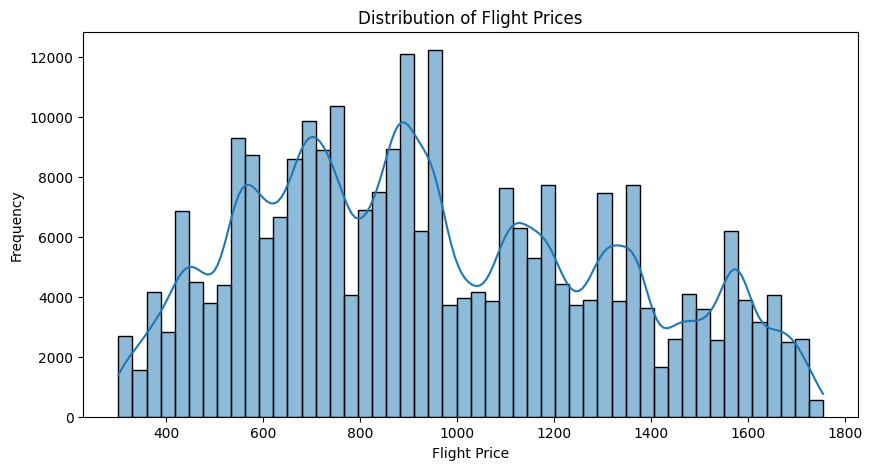

In [ ]:
#  EDA 1: Check the distribution of flight prices

plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of Flight Prices")
plt.xlabel("Flight Price")
plt.ylabel("Frequency")
plt.show()

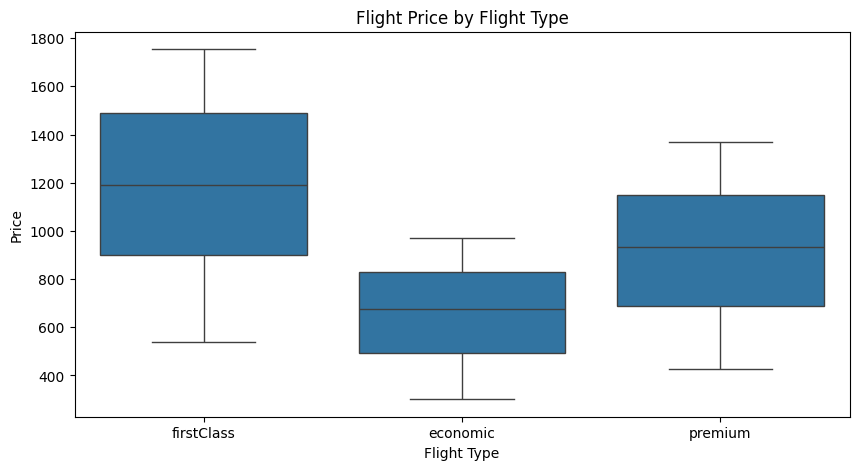

In [ ]:
# EDA 2: Flight Type vs Price

plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="flightType", y="price")

plt.title("Flight Price by Flight Type")
plt.xlabel("Flight Type")
plt.ylabel("Price")

plt.show()

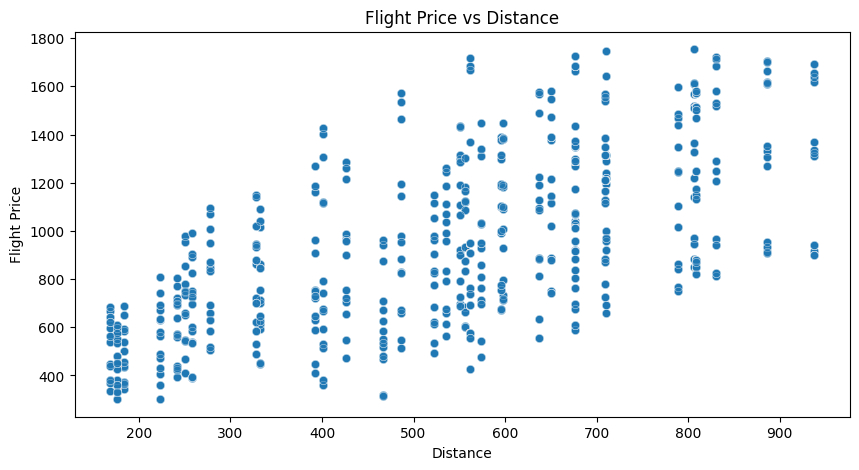

In [ ]:
# EDA 3: Flight Price vs Distance

plt.figure(figsize=(10, 5))

sns.scatterplot(data=df, x="distance", y="price", alpha=0.4)

plt.title("Flight Price vs Distance")
plt.xlabel("Distance")
plt.ylabel("Flight Price")

plt.show()

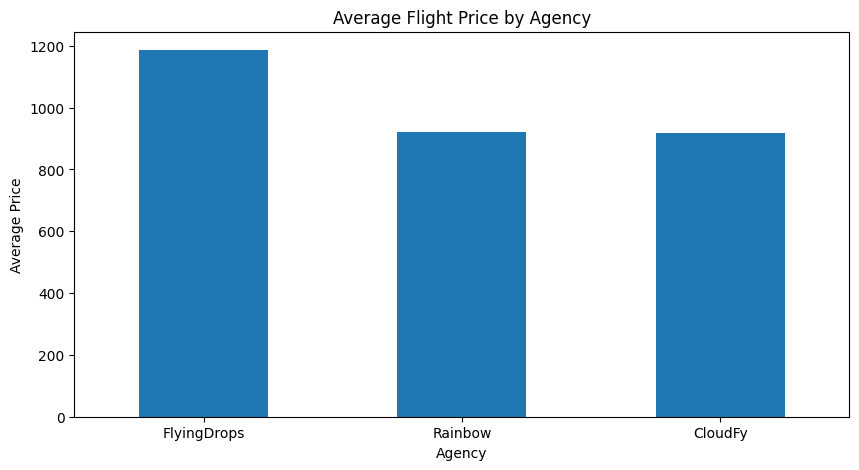

In [ ]:
# EDA 4: Average Flight Price by Agency

agency_price = df.groupby("agency")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

agency_price.plot(kind="bar")

plt.title("Average Flight Price by Agency")
plt.xlabel("Agency")
plt.ylabel("Average Price")

plt.xticks(rotation=0)
plt.show()

<Figure size 1000x500 with 0 Axes>

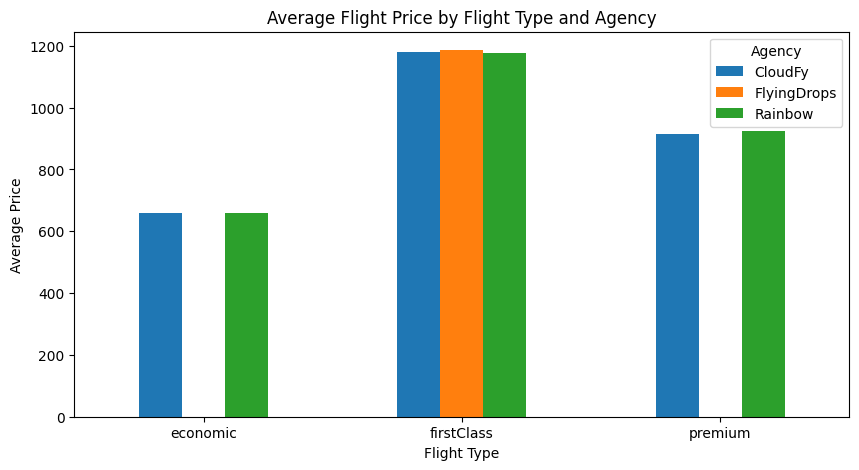

In [ ]:
# EDA 5: Average Flight Price by Flight Type and Agency

price_comparison = df.groupby(
    ["flightType", "agency"]
)["price"].mean().unstack()

plt.figure(figsize=(10, 5))

price_comparison.plot(kind="bar", figsize=(10, 5))

plt.title("Average Flight Price by Flight Type and Agency")
plt.xlabel("Flight Type")
plt.ylabel("Average Price")

plt.xticks(rotation=0)
plt.legend(title="Agency")
plt.show()

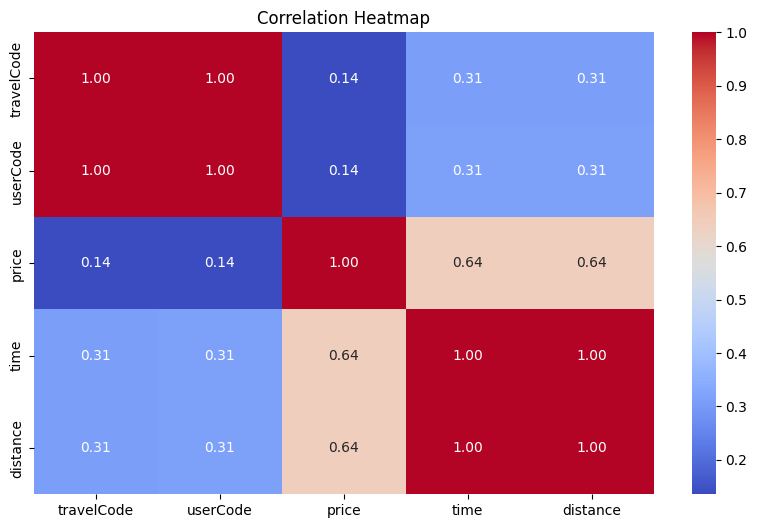

In [ ]:
# EDA 6: Correlation Heatmap

numeric_cols = ["travelCode", "userCode", "price", "time", "distance"]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

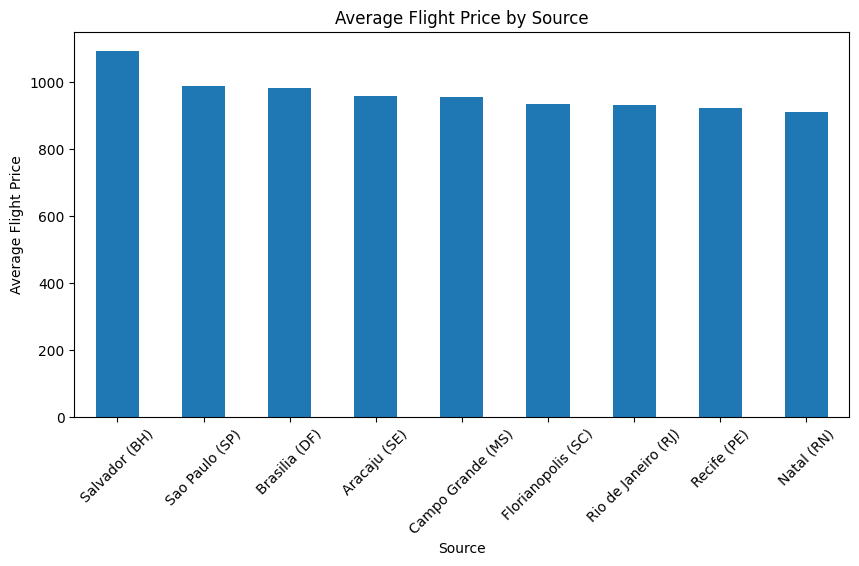

In [ ]:
# EDA 7: Average Flight Price by Source

source_price = (
    df.groupby("from")["price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

source_price.plot(kind="bar")

plt.title("Average Flight Price by Source")
plt.xlabel("Source")
plt.ylabel("Average Flight Price")

plt.xticks(rotation=45)
plt.show()

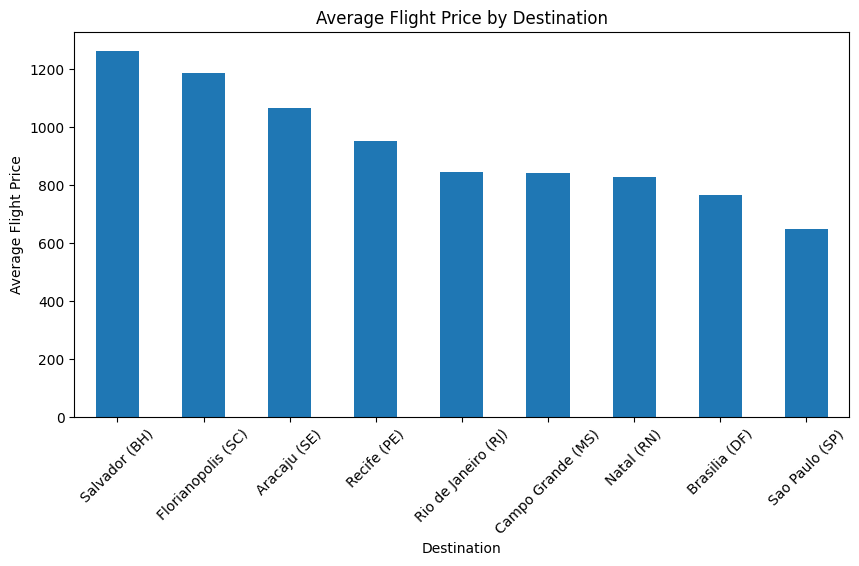

In [ ]:
# EDA 8: Average Flight Price by Destination

destination_price = (
    df.groupby("to")["price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

destination_price.plot(kind="bar")

plt.title("Average Flight Price by Destination")
plt.xlabel("Destination")
plt.ylabel("Average Flight Price")

plt.xticks(rotation=45)
plt.show()

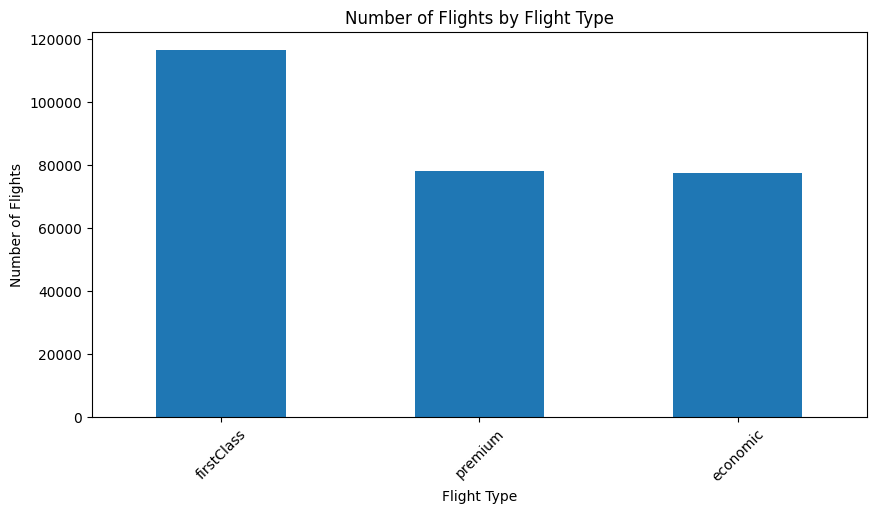

In [ ]:
# EDA 9: Flight Count by Flight Type

flight_type_count = df["flightType"].value_counts()

plt.figure(figsize=(10, 5))

flight_type_count.plot(kind="bar")

plt.title("Number of Flights by Flight Type")
plt.xlabel("Flight Type")
plt.ylabel("Number of Flights")

plt.xticks(rotation=45)
plt.show()

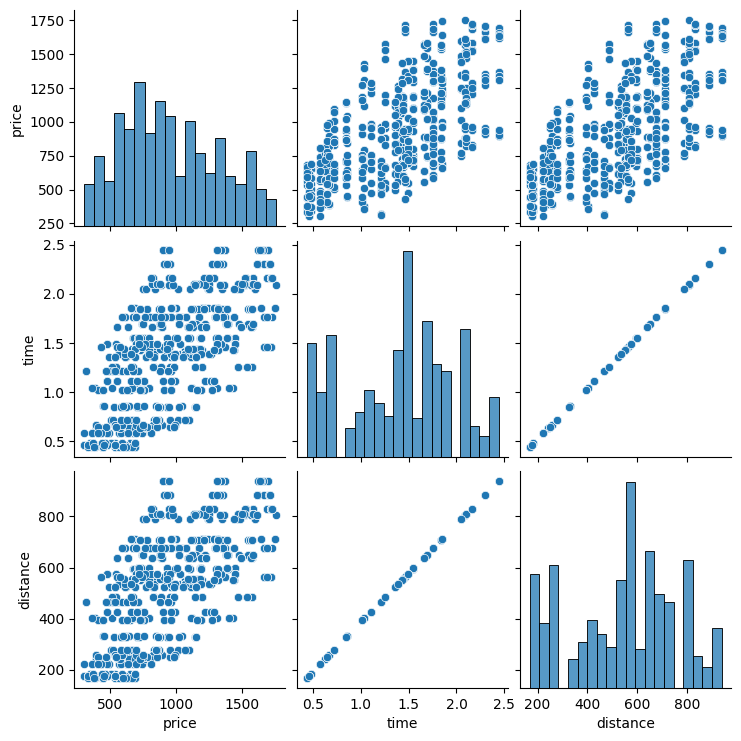

In [ ]:
# EDA 10: Pair Plot of Important Numerical Features

pairplot_data = df[["price", "time", "distance"]].sample(
    n=min(3000, len(df)),
    random_state=42
)

sns.pairplot(pairplot_data, diag_kind="hist")

plt.show()

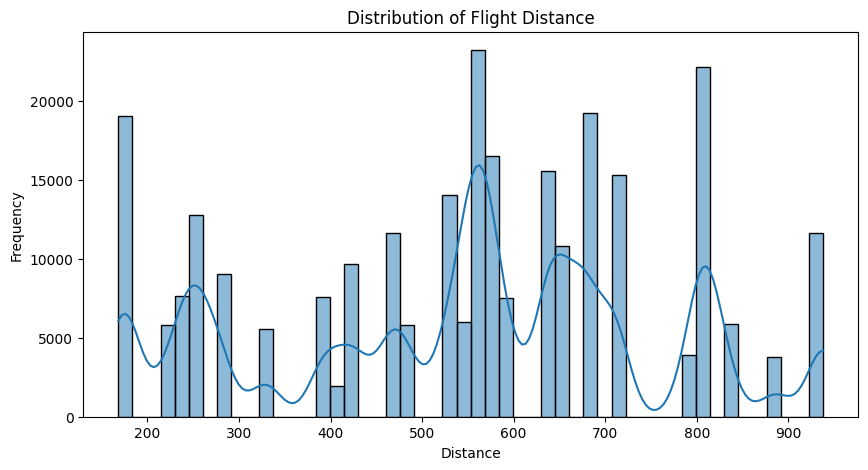

In [ ]:
# EDA 11: Distribution of Flight Distance

plt.figure(figsize=(10, 5))

sns.histplot(df["distance"], bins=50, kde=True)

plt.title("Distribution of Flight Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.show()

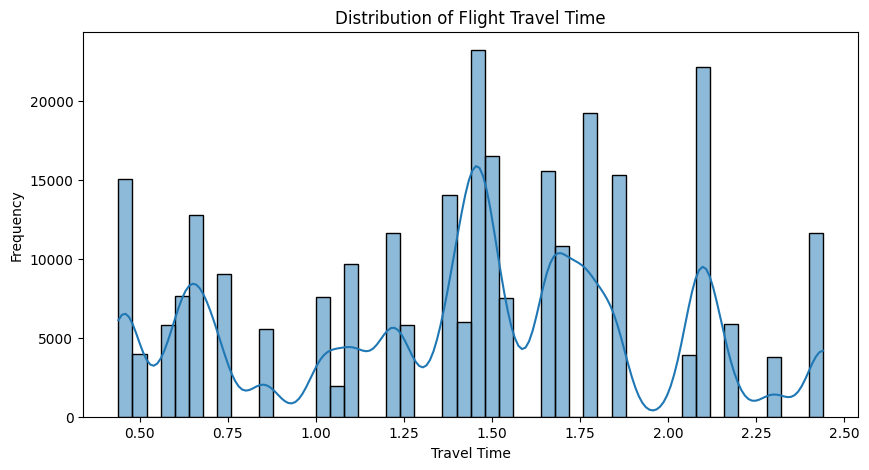

In [ ]:
# EDA 12: Distribution of Travel Time

plt.figure(figsize=(10, 5))

sns.histplot(df["time"], bins=50, kde=True)

plt.title("Distribution of Flight Travel Time")
plt.xlabel("Travel Time")
plt.ylabel("Frequency")

plt.show()

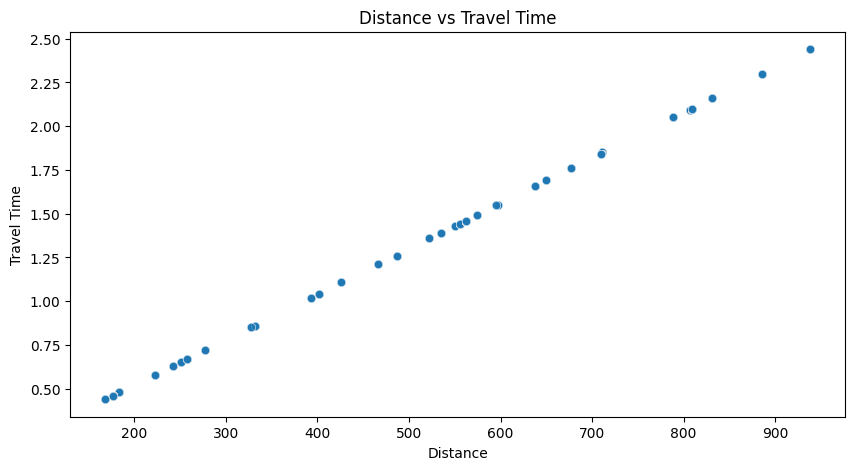

In [ ]:
# EDA 13: Distance vs Travel Time

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="distance",
    y="time",
    alpha=0.4
)

plt.title("Distance vs Travel Time")
plt.xlabel("Distance")
plt.ylabel("Travel Time")

plt.show()

## 6. Data Preprocessing

In [59]:
# Check data types

print("Data Types:")
print(df.dtypes)

Data Types:
travelCode              int64
userCode                int64
from                   object
to                     object
flightType             object
price                 float64
time                  float64
distance              float64
agency                 object
date           datetime64[ns]
year                    int32
month                   int32
day                     int32
day_of_week             int32
dtype: object


In [60]:
# Convert date column to datetime

df["date"] = pd.to_datetime(df["date"])

print("Date column converted successfully!")
print(df["date"].dtype)

Date column converted successfully!
datetime64[ns]


In [61]:
# Extract date features

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

print("Date features created successfully!")

df[["date", "year", "month", "day", "day_of_week"]].head()

Date features created successfully!


,date,year,month,day,day_of_week
0,2019-09-26,2019,9,26,3
1,2019-09-30,2019,9,30,0
2,2019-10-03,2019,10,3,3
3,2019-10-04,2019,10,4,4
4,2019-10-10,2019,10,10,3


In [77]:
# Define features (X) and target (y)

X = df.drop(columns=["price", "date"])
y = df["price"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features (X) shape: (271888, 12)
Target (y) shape: (271888,)

Feature columns:
['travelCode', 'userCode', 'from', 'to', 'flightType', 'time', 'distance', 'agency', 'year', 'month', 'day', 'day_of_week']


## 7. Feature Selection

In [70]:
# Select relevant features for flight price prediction

selected_features = [
    "from",
    "to",
    "flightType",
    "time",
    "distance",
    "agency",
    "year",
    "month",
    "day",
    "day_of_week"
]

X = df[selected_features]
y = df["price"]

print("Selected Features:")
print(selected_features)

print("\nTarget:")
print("price")

print("\nX shape:", X.shape)

Selected Features:
['from', 'to', 'flightType', 'time', 'distance', 'agency', 'year', 'month', 'day', 'day_of_week']

Target:
price

X shape: (271888, 10)


### 8. Train-Test Split

In [71]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (217510, 10)
Testing data shape: (54378, 10)


## 9. Feature Preprocessing

In [73]:
# Identify numerical and categorical columns

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['time', 'distance', 'year', 'month', 'day', 'day_of_week']

Categorical features:
['from', 'to', 'flightType', 'agency']


In [74]:
# Create preprocessing pipelines

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [75]:
# Apply preprocessing to training and testing data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (217510, 30)
Processed testing data shape: (54378, 30)


## 10. Model Training

In [76]:
# Train Random Forest Regression model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## 11.Model Evaluation

In [78]:
# Make predictions on test data

y_pred = model.predict(X_test_processed)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation Results
------------------------
MAE : 0.04256097135158889
MSE : 0.3814051371505264
RMSE: 0.6175800653765683
R²  : 0.9999971055062467


## 12. Actual vs Predicted Prices

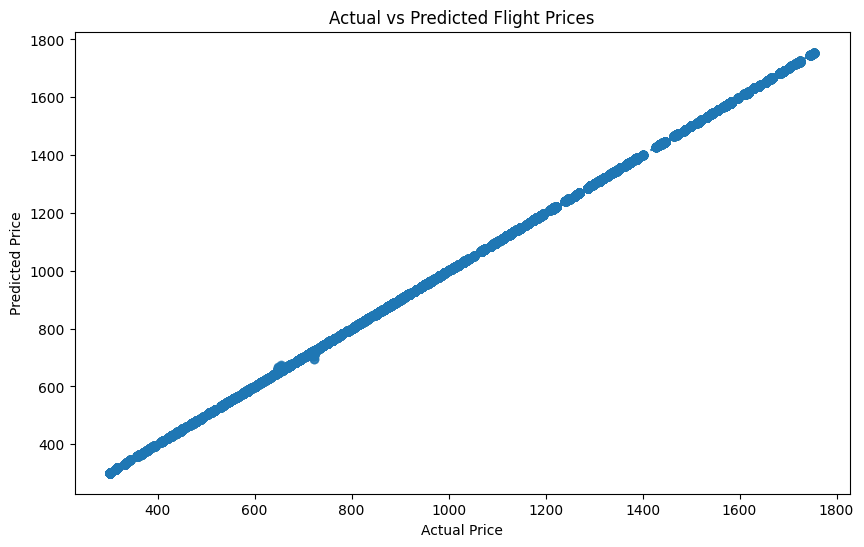

In [79]:
# Compare actual and predicted prices

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

## 13. Residual Analysis

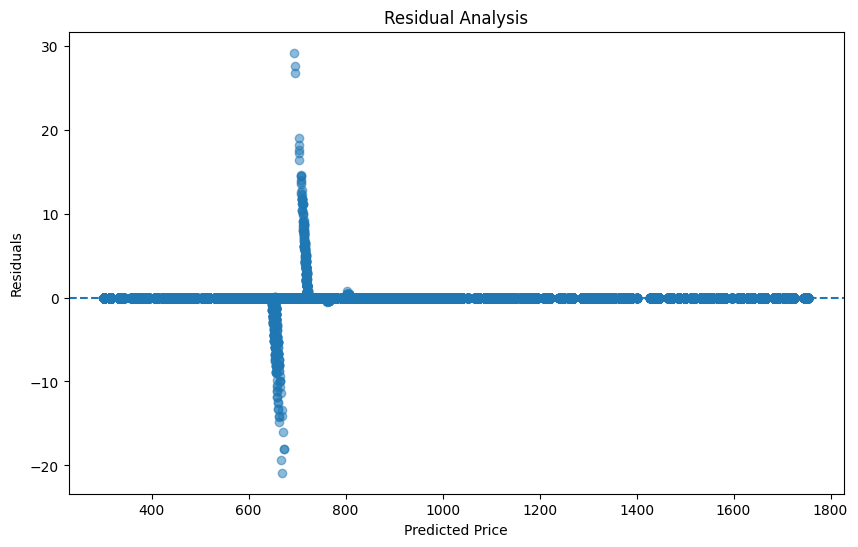

In [80]:
# Calculate residuals

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Analysis")

plt.show()

## 14. Feature Importance

In [81]:
# Get feature importance from Random Forest

feature_importance = model.feature_importances_

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
display(importance_df.head(15))

Top 15 Important Features:


,Feature,Importance
25,cat__flightType_firstClass,0.296597
0,num__time,0.238492
1,num__distance,0.234380
26,cat__flightType_premium,0.068172
9,cat__from_Florianopolis (SC),0.047432
15,cat__to_Aracaju (SE),0.021540
18,cat__to_Florianopolis (SC),0.018382
14,cat__from_Sao Paulo (SP),0.011533
7,cat__from_Brasilia (DF),0.008962
24,cat__flightType_economic,0.008759


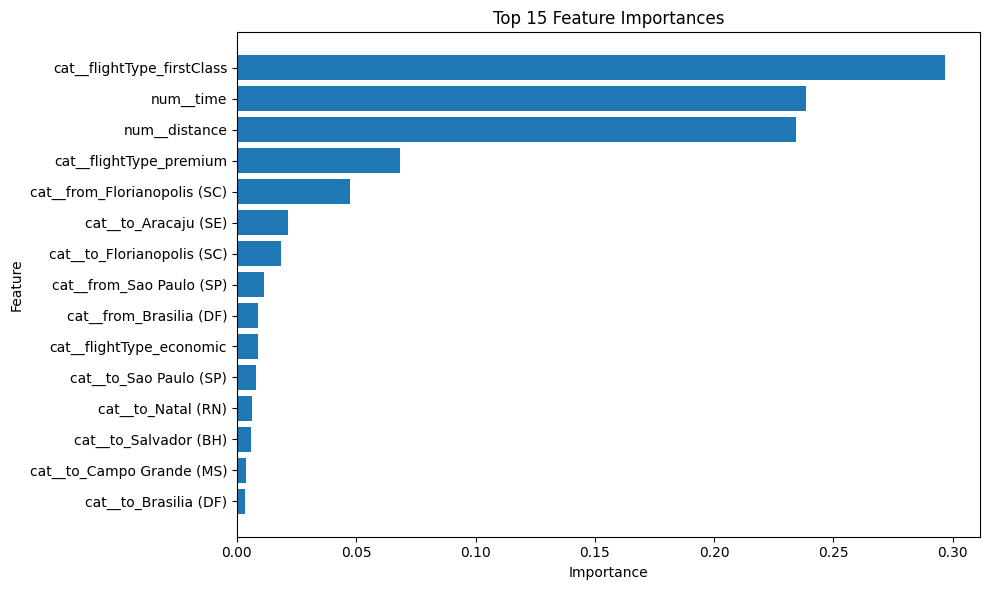

In [82]:
# Plot top 15 feature importances

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.tight_layout()
plt.show()

## 15. Model Saving

In [83]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [84]:
import joblib
import os

model_folder = "/content/drive/MyDrive/Project MLOPS/models"
os.makedirs(model_folder, exist_ok=True)

joblib.dump(model, model_folder + "/flight_price_model.pkl")
joblib.dump(preprocessor, model_folder + "/flight_price_preprocessor.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


## Conclusion

This project successfully developed a machine learning model to predict flight prices using flight details such as flight type, travel time, distance, source, destination, and agency. Exploratory Data Analysis helped identify patterns and relationships in the dataset. Data preprocessing was performed using numerical transformation and one-hot encoding for categorical features.
The Random Forest Regressor performed very well, achieving an R² score of approximately 0.999999, with very low MAE and RMSE. Feature importance showed that flight type, travel time, and distance were the most influential factors in predicting flight prices.
The trained model and preprocessing pipeline were successfully saved using Joblib and can be integrated into an API for real-time flight price prediction.